# Post-Treatement of the data
The aim of this notebook is to import the different simulations, and compute the different indices of quality as well as the volume.  
The indices we calculate are the following for the synthetic :
1. Sum of the error 
2. Absolute sum of the error
3. Normalized Sum
4. Standard Deviation
5. Mean

For the real data, we just compute the volume.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import pickle
import os
import time
from matplotlib.backends.backend_pdf import PdfPages


Define the path of the data

In [9]:
path_output_krig = 'simulation_output_krig/'
path_output_MPS = 'simulation_output/'

simulation_name_krig = os.listdir(path_output_krig)
simulation_name = os.listdir(path_output_MPS)

exec(open('./functions/05_indice_Calculation.py').read())


In the following cell, we will generate the 

In [10]:

all_output = []
real_vol = []
type_sim = ['MPS1','MPS2','GRF','KRIG']
for name, name_krig in zip(simulation_name,simulation_name_krig):
    it = 0
    with open(path_output_MPS+name,'rb') as file:
        real_alt, simus_sets = pickle.load(file)
    
    with open(path_output_krig+name_krig,'rb') as file:
         real_k, krieg_sets = pickle.load(file)

    for simus in simus_sets:        
        pro = indice_calculation(real_alt,simus,'mps')
        
        all_output.append([name,type_sim[it]] + pro)
        it = it + 1
        
        
    pro = indice_calculation(real_k,krieg_sets,'krig')
    all_output.append([name,type_sim[it]] + pro)
results_frame = pd.DataFrame(data =all_output, columns=['Sim_name','Type','Error','Abs_error','Norm_Error','Mean','Sd','Volume'])

real_vol = np.sum(real_alt-real_alt+50) 

C:\Users\nevena\AppData\Local\Continuum\anaconda3\envs\Pyclass36\lib\site-packages\ipykernel_launcher.py:83: RuntimeWarning: divide by zero encountered in true_divide
C:\Users\nevena\AppData\Local\Continuum\anaconda3\envs\Pyclass36\lib\site-packages\ipykernel_launcher.py:83: RuntimeWarning: invalid value encountered in true_divide
C:\Users\nevena\AppData\Local\Continuum\anaconda3\envs\Pyclass36\lib\site-packages\ipykernel_launcher.py:49: RuntimeWarning: invalid value encountered in true_divide


In [11]:
%xmode plain

Exception reporting mode: Plain


In [12]:
#np.shape(real_alt)
#real_alt.shape
simus_sets
results_frame

,Sim_name,Type,Error,Abs_error,Norm_Error,Mean,Sd,Volume
0,realisation0_simu.pickle,MPS1,0.495844,1.586303,8.724322,"[[2799.2965449580443, 2799.02880859375, 2798.4...","[[0.16804240927440034, 0.0, 0.1348038039551288...","[31289.341967545875, 30056.433554683863, 31261..."
1,realisation0_simu.pickle,MPS2,0.413549,1.503478,25.263213,"[[2799.9116821289062, 2799.02880859375, 2799.0...","[[0.2922037640834555, 0.0, 0.22368672688905192...","[31277.27497259708, 31001.940354608356, 31001...."
2,realisation0_simu.pickle,GRF,2.347967,2.484060,13.901464,"[[2799.257080078125, 2798.869873046875, 2798.5...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[30190.06115343765, 29715.870590036757, 30113...."
3,realisation0_simu.pickle,KRIG,2.156432,2.156905,2.671672,"[[2799.257080078125, 2798.869873046875, 2798.5...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",[30178.253394322193]
4,realisation1_simu.pickle,MPS1,-0.120531,0.854836,5.491015,"[[2661.192626953125, 2660.789306640625, 2660.4...","[[0.0, 0.0, 0.07916048579542714, 0.09972068185...","[31572.347722306877, 31112.233664527343, 31603..."
5,realisation1_simu.pickle,MPS2,-0.464963,1.122389,3.774798,"[[2661.192626953125, 2660.789306640625, 2660.3...","[[0.0, 0.0, 0.1760626013006448, 0.194900442544...","[31545.895311144297, 31299.077989582413, 31414..."
6,realisation1_simu.pickle,GRF,2.171646,2.322520,13.878187,"[[2661.554443359375, 2661.112060546875, 2660.6...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[30026.697297041963, 30539.493335362942, 29971..."
7,realisation1_simu.pickle,KRIG,2.005457,2.005988,1.991250,"[[2661.554443359375, 2661.112060546875, 2660.6...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",[30237.244191994814]


In [13]:
len(simus_sets[0])

4

In [14]:
real_vol

31250.0

In [15]:
dirName ='simu_reports'
numbers = []
try:
    # Create target Directory
    os.mkdir(dirName)
    print("Directory " , dirName ,  " Created ") 
    pdf_name = 'pdf_report_001.pdf'
except FileExistsError:
    print("Directory " , dirName ,  " already exists")
    pdf_name = os.listdir(dirName)
    for pdf_me in pdf_name:
        numbers.append(pdf_me[11:12])
    pdf_name = 'pdf_report_'+ str(int(max(numbers))+1).rjust(3, '0')+'.pdf' 


Directory  simu_reports  already exists


In [16]:
pdf_name

'pdf_report_010.pdf'

Text(0, 0.5, 'Error [m]')

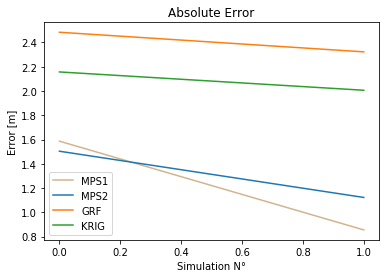

In [17]:
plt.plot(results_frame[results_frame['Type']=='MPS1'].Abs_error.values,color='tan')
plt.plot(results_frame[results_frame['Type']=='MPS2'].Abs_error.values)
plt.plot(results_frame[results_frame['Type']=='GRF'].Abs_error.values)
plt.plot(results_frame[results_frame['Type']=='KRIG'].Abs_error.values)
plt.legend(['MPS1','MPS2','GRF','KRIG'])
plt.title('Absolute Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')
#plt.plot(np.ones(len(pts_0))*2,color='grey',ls='--')


Text(0, 0.5, 'Error [m]')

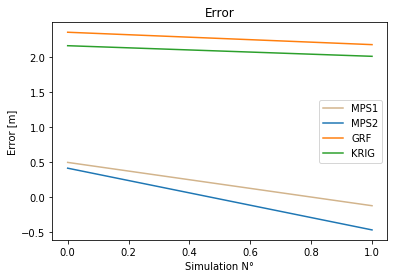

In [20]:
plt.plot(results_frame[results_frame['Type']=='MPS1'].Error.values,color='tan')
plt.plot(results_frame[results_frame['Type']=='MPS2'].Error.values)
plt.plot(results_frame[results_frame['Type']=='GRF'].Error.values)
plt.plot(results_frame[results_frame['Type']=='KRIG'].Error.values)
plt.legend(['MPS1','MPS2','GRF','KRIG'])
plt.title('Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')

#plt.plot(np.ones(len(pts_0))*0,color='grey',ls='--')

Text(0, 0.5, 'Error [m]')

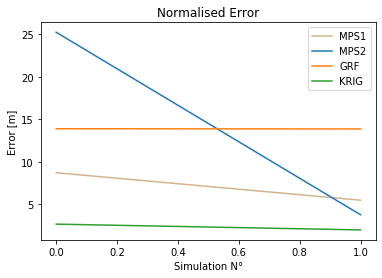

In [21]:
plt.plot(results_frame[results_frame['Type']=='MPS1'].Norm_Error.values,color='tan')
plt.plot(results_frame[results_frame['Type']=='MPS2'].Norm_Error.values)
plt.plot(results_frame[results_frame['Type']=='GRF'].Norm_Error.values)
plt.plot(results_frame[results_frame['Type']=='KRIG'].Norm_Error.values)
plt.legend(['MPS1','MPS2','GRF','KRIG'])
plt.title('Normalised Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')
#plt.plot(np.ones(len(pts_0))*1,color='grey',ls='--')


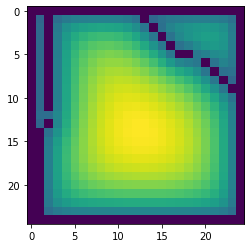

In [23]:
plt.imshow(results_frame[results_frame['Type']=='KRIG'].Sd.values[0])

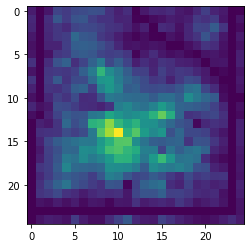

In [24]:
plt.imshow(results_frame[results_frame['Type']=='MPS2'].Sd.values[0])

In [25]:
vol_MPS1 = []
vol_MPS2 = []
vol_KRIG = []
vol_GRF = []


for i in range(int(results_frame.shape[0]/4)):
    vol_MPS1.extend(results_frame[results_frame['Type']=='MPS1'].Volume.values[i][:])
    vol_MPS2.extend(results_frame[results_frame['Type']=='MPS2'].Volume.values[i])
    vol_KRIG.extend(results_frame[results_frame['Type']=='KRIG'].Volume.values[i])
    vol_GRF.extend(results_frame[results_frame['Type']=='GRF'].Volume.values[i])

    


Text(0.5, 0, 'Volume [m^2]')

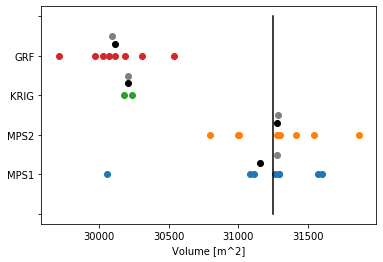

In [28]:
plt.scatter(vol_MPS1,np.ones(len(vol_MPS1)))
plt.scatter(vol_MPS2,np.ones(len(vol_MPS2))+1)
plt.scatter(vol_KRIG,np.ones(len(vol_KRIG))+2)
plt.scatter(vol_GRF,np.ones(len(vol_GRF))+3)
plt.plot([real_vol, real_vol],[0,5],color = 'black')

plt.scatter(np.mean(vol_MPS1),1.3,color = 'black')
plt.scatter(np.mean(vol_MPS2),2.3,color = 'black')
plt.scatter(np.mean(vol_KRIG),3.3,color = 'black')
plt.scatter(np.mean(vol_GRF),4.3,color = 'black')

#plt.text(np.mean(vol_MPS1)+30000,1.3,'Mean')
#plt.text(np.mean(vol_MPS2)+30000,2.3,'Mean')
#plt.text(np.mean(vol_KRIG)+30000,3.3,'Mean')
#plt.text(np.mean(vol_GRF)+30000,4.3,'Mean')

plt.scatter(np.median(vol_MPS1),1.5,color = 'grey')
plt.scatter(np.median(vol_MPS2),2.5,color = 'grey')
plt.scatter(np.median(vol_KRIG),3.5,color = 'grey')
plt.scatter(np.median(vol_GRF),4.5,color = 'grey')

#plt.text(np.median(vol_MPS1)+30000,1.5,'Median')
#plt.text(np.median(vol_MPS2)+30000,2.5,'Median')
#plt.text(np.median(vol_KRIG)+30000,3.5,'Median')
#plt.text(np.median(vol_GRF)+30000,4.5,'Median')

ax = plt.gca()

labels = [item.get_text() for item in ax.get_yticklabels()]
labels[1] = 'Testing'
ax.set_yticklabels(['','','MPS1','MPS2','KRIG','GRF'])



plt.xlabel('Volume [m^2]')